In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1pkLk2s89-Etn7zIuYV88L_FvDH3sI8qx')
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta
0,0,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Nuttee,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.43,4.95
1,1,previous scrape,"Easy going landlord,easy place",Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Emy,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
2,2,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,Familyroom,12/05/2010,"Bangkok, Thailand",Welcome to Familyroom Apartment.\r\n\r\nA Chic...,within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
3,3,city scrape,Spacious one bedroom at The Kris Condo Bldg. 3,Cozy and clean apartment at MRT Sutthisarn sta...,"There is McDonald's, Au bon Pain and Max Value...",Sirilak,27/06/2010,"Bangkok, Thailand",from Bangkok but I'm in and out of the city a ...,within an hour,...,0.0,4.83,5.00,4.67,4.50,4.83,4.83,5.00,0.06,5.00
4,4,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,"There is McDonald's, Au bon Pain and Max Value...",Athitaya,03/09/2010,"Bangkok, Thailand","Full-time legal consultant from Bangkok, Thail...",within an hour,...,0.0,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.01,5.00


In [ ]:
df = df[df['room_type'] == 'Private room']

In [4]:
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace('.00', '', regex=False)
df['price'] = df['price'].str.replace(',000', '', regex=False)
df['price'] = df['price'].str.replace(',', '.', regex=False)
df['price'] = df['price'].astype(float)

<ipython-input-5-2a2118cb5fef>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


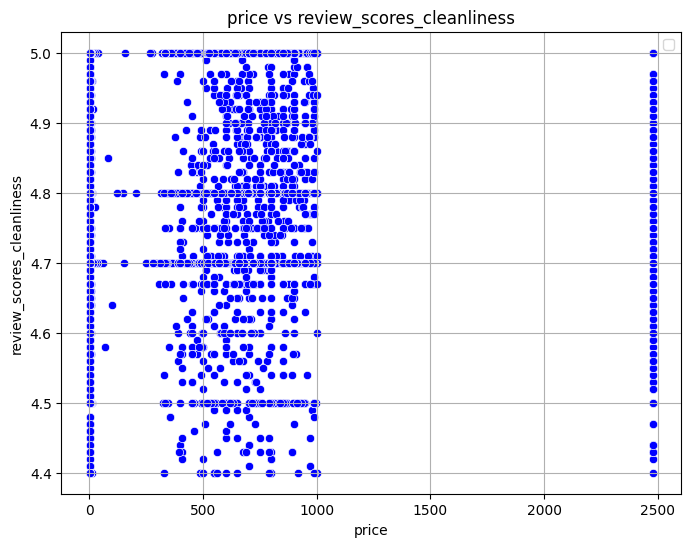

In [5]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='review_scores_cleanliness', x='price',  color = 'blue', data=df)
plt.title('price vs review_scores_cleanliness')
plt.xlabel('price')
plt.ylabel('review_scores_cleanliness')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
indep= df[['review_scores_cleanliness']]
dep = df[['price']]

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [8]:
model.fit(indep, dep)

LinearRegression()

In [9]:
type(model)

sklearn.linear_model._base.LinearRegression

In [10]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['review_scores_cleanliness'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[-1058.39919556]]),
 'rank_': 1,
 'singular_': array([12.27741235]),
 'intercept_': array([6076.9475046])}

In [11]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[-1058.39919556]]
Intercepto: [6076.9475046]
y = [-1058.39919556]x + [6076.9475046]


In [12]:
r2 = model.score(indep, dep)
r2

0.018013605620233686

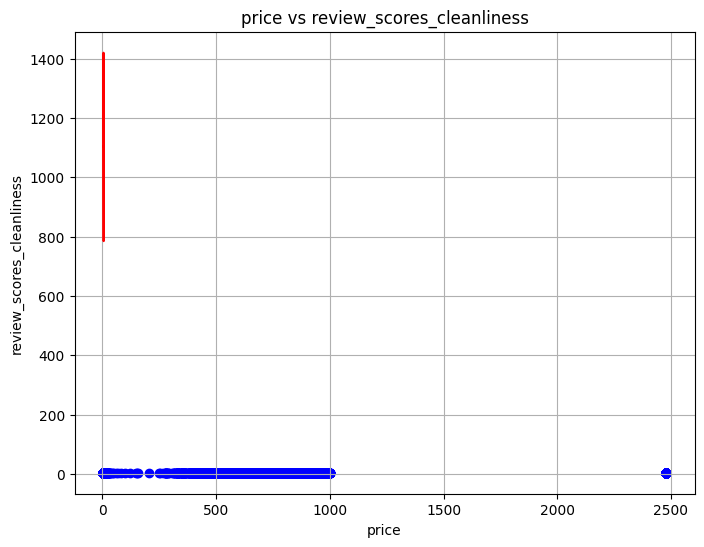

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('price vs review_scores_cleanliness')
plt.xlabel('price')
plt.ylabel('review_scores_cleanliness')
plt.grid(True)
plt.show()

In [14]:
yPred = model.predict(df[['review_scores_cleanliness']])
yPred

array([[1102.47128545],
       [1102.47128545],
       [1134.22326131],
       ...,
       [1102.47128545],
       [1102.47128545],
       [1102.47128545]])

In [15]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta,Predicciones
1,1,previous scrape,"Easy going landlord,easy place",Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Emy,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,4.70,4.7,4.70,4.80,4.80,4.60,4.70,1.00,4.7,1102.471285
2,2,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,Familyroom,12/05/2010,"Bangkok, Thailand",Welcome to Familyroom Apartment.\r\n\r\nA Chic...,within an hour,...,4.70,4.7,4.70,4.80,4.80,4.60,4.70,1.00,4.7,1102.471285
3,3,city scrape,Spacious one bedroom at The Kris Condo Bldg. 3,Cozy and clean apartment at MRT Sutthisarn sta...,"There is McDonald's, Au bon Pain and Max Value...",Sirilak,27/06/2010,"Bangkok, Thailand",from Bangkok but I'm in and out of the city a ...,within an hour,...,4.83,5.0,4.67,4.50,4.83,4.83,5.00,0.06,5.0,1134.223261
4,4,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,"There is McDonald's, Au bon Pain and Max Value...",Athitaya,03/09/2010,"Bangkok, Thailand","Full-time legal consultant from Bangkok, Thail...",within an hour,...,5.00,5.0,5.00,5.00,5.00,5.00,5.00,0.01,5.0,784.951527
5,5,city scrape,Sathorn Terrace Apartment(61),at a size of 25sqm for your vacation in BKK.<b...,"There is McDonald's, Au bon Pain and Max Value...",Tor,15/10/2010,"Bangkok, Thailand","Hello, my name is Tor, Escape at sathorn terra...",within a few hours,...,4.79,4.7,4.85,4.82,4.88,4.76,4.84,0.21,4.7,943.711406


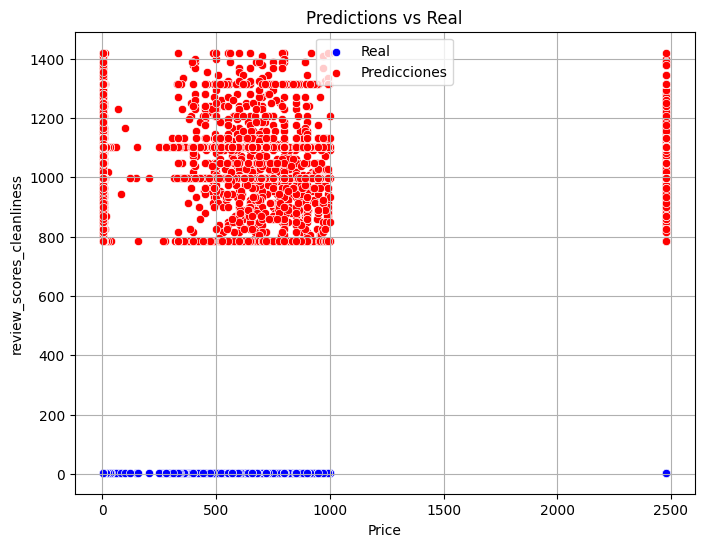

In [16]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='review_scores_cleanliness', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('review_scores_cleanliness')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
coefDe = model.score(indep, dep)
coefDe

0.018013605620233686

In [ ]:
coefCo = np.sqrt(coefDe)
coefCo

0.018013605620233686